In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [6]:
#Load datasets
df1 = pd.read_csv('1.csv')
df2=  pd.read_csv('2.csv')

In [7]:
#merge datasets
df= pd.merge(df1, df2, on='Policy no.')

In [8]:
df.head()

,Policy no.,children,smoker,region,age,sex,bmi,charges in INR
0,PLC157006,0,no,southwest,23,male,34.4,1826.843
1,PLC157033,1,no,southwest,19,male,24.6,1837.237
2,PLC157060,0,no,southwest,56,male,40.3,10602.385
3,PLC157087,1,no,southwest,30,female,32.4,4149.736
4,PLC157186,5,no,southwest,19,female,28.6,4687.797


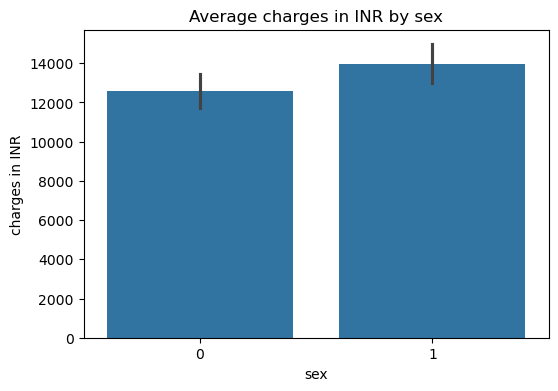

In [11]:
#1 gender of the person matter for the company 
plt.figure(figsize=(6,4))
sns.barplot(x=df['sex'], y=df['charges in INR'])
plt.title('Average charges in INR by sex')
plt.xlabel('sex')
plt.ylabel('charges in INR')
plt.show()

Average Amount spent per policy: Rs 13270.42


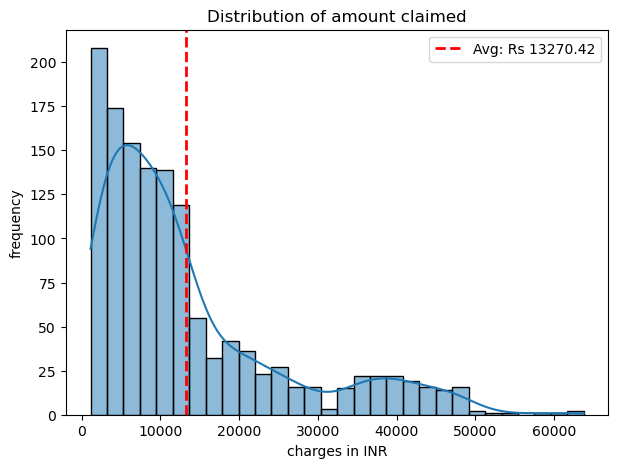

In [41]:
#2 average amount of money the company spent over each policy
average_spent = df['charges in INR'].mean()

print(f"Average Amount spent per policy: Rs {average_spent:.2f}")

plt.figure(figsize=(7,5))
sns.histplot(df['charges in INR'], bins=30, kde=True)

plt.axvline(
    average_spent,
    color='red',
    linestyle='dashed',
    linewidth=2,
    label=f'Avg: Rs {average_spent:.2f}'
)

plt.title('Distribution of amount claimed')
plt.xlabel('charges in INR')
plt.ylabel('frequency')
plt.legend()
plt.show()



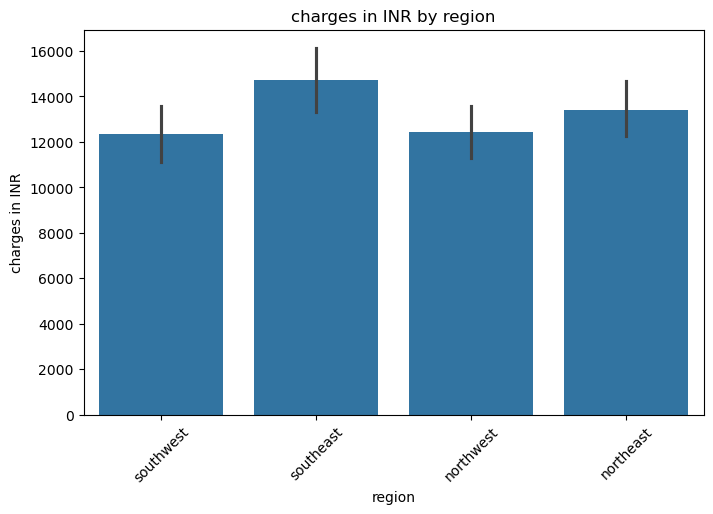

In [11]:
#3 policies based upon the geographic location of the person
import matplotlib.pyplot as plt
plt.figure(figsize=[8,5])
sns.barplot(x=df['region'], y=df['charges in INR'])
plt.xticks(rotation=45)
plt.title('charges in INR by region')
plt.xlabel('region')
plt.ylabel('charges in INR')
plt.show()



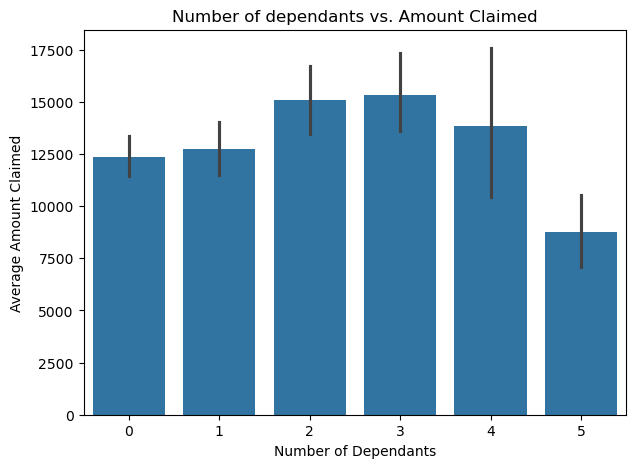

In [42]:
#4 no. of dependents make a difference in the amount claimed
plt.figure(figsize=[7,5])
sns.barplot(x=df['children'], y=df['charges in INR'])
plt.title('Number of dependants vs. Amount Claimed')
plt.xlabel('Number of Dependants')
plt.ylabel('Average Amount Claimed')
plt.show()


In [25]:
#Categorize age range
def age_category(age):
    if  age < 20:
      return "<20"
    elif age <= 40:
      return "20-40"
    elif age <= 60:
      return "40-60"
    else:
      return ">60"

df['age_Range']= df['age'].apply(age_category)
df[['age', 'age_Range']].head()

,age,age_Range
0,23,20-40
1,19,<20
2,56,40-60
3,30,20-40
4,19,<20


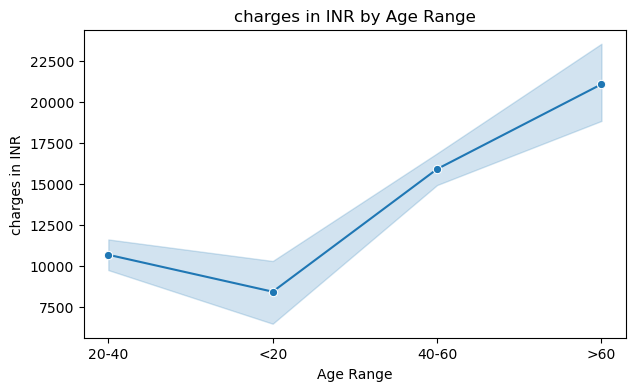

In [28]:
# Age have any barrier on the insurance claimed
plt.figure(figsize=(7,4))
sns.lineplot(x=df['age_Range'], y=df['charges in INR'], marker='o')
plt.title('charges in INR by Age Range')
plt.xlabel('Age Range')
plt.ylabel('charges in INR')
plt.show()

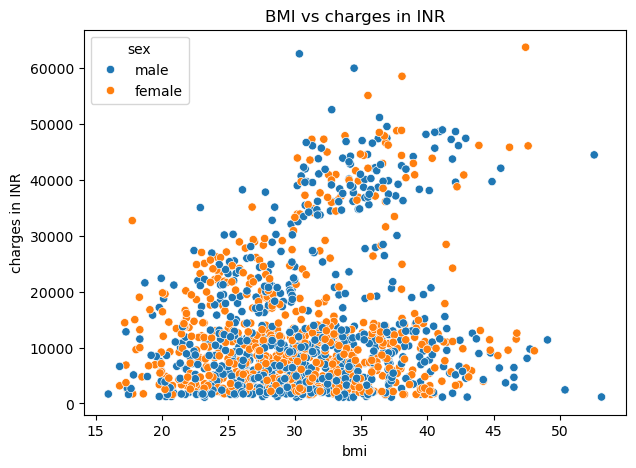

In [29]:
#persons BMI on the Insurance claim
plt.figure(figsize=(7,5))
sns.scatterplot(x=df['bmi'], y=df['charges in INR'], hue=df['sex'])
plt.title('BMI vs charges in INR')
plt.xlabel('bmi')
plt.ylabel('charges in INR')
plt.show()

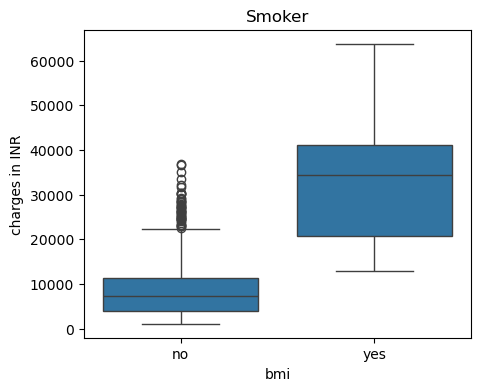

In [30]:
#  person covered is a smoker or a non-smoker
plt.figure(figsize=(5,4))
sns.boxplot(x=df['smoker'], y=df['charges in INR'])
plt.title('Smoker')
plt.xlabel('bmi')
plt.ylabel('charges in INR')
plt.show()

In [50]:
#8 discounts after checking the health status BMI
def bmi_category(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi<=24.9:
        return "Normal weight"
    elif bmi<=29.9:
        return "Overweight"
    else:
        return "Obese"

df['BMI_Category'] = df['bmi'].apply(bmi_category)
df[['bmi', 'BMI_Category']].head()

,bmi,BMI_Category
0,34.4,Obese
1,24.6,Normal weight
2,40.3,Obese
3,32.4,Obese
4,28.6,Overweight


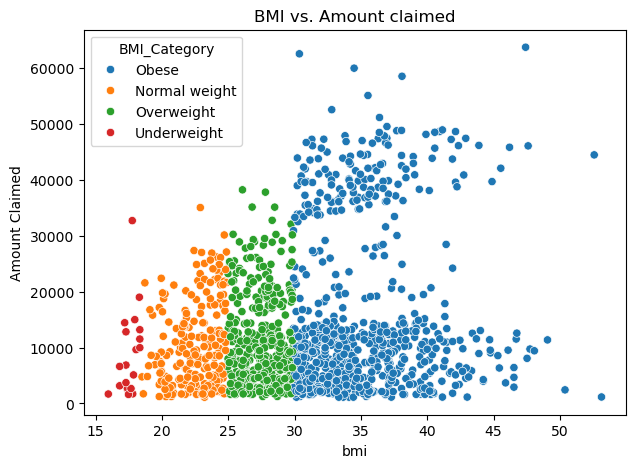

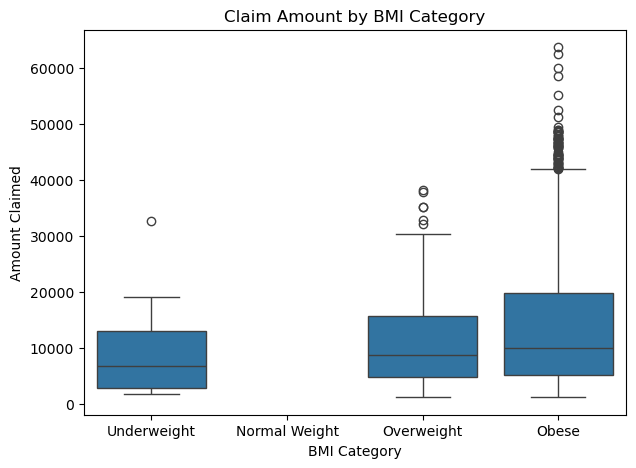

In [51]:
#Scatter plot- BMI vs Amount claimed
plt.figure(figsize=(7,5))
sns.scatterplot(x=df['bmi'], y=df['charges in INR'], hue=df['BMI_Category'])
plt.title('BMI vs. Amount claimed')
plt.xlabel('bmi')
plt.ylabel('Amount Claimed')
plt.show()

#Boxplot : BMI Category Vs. Amount claimed
plt.figure(figsize=(7,5))
sns.boxplot(x=df['BMI_Category'], y=df['charges in INR'],order=['Underweight','Normal Weight', 'Overweight', 'Obese'])
plt.title('Claim Amount by BMI Category')
plt.xlabel('BMI Category')
plt.ylabel('Amount Claimed')
plt.show()